In [4]:
data_directory = "data/ravdess"

In [3]:
root_path = '/'

In [4]:
import os
os.chdir(root_path)

In [12]:
mkdir -p datasets/ravdess


In [14]:
import os

# Define the data directory
data_directory = "data"

# Check if the directory exists, if not create it
if not os.path.exists(data_directory):
    os.makedirs(data_directory)


!unzip data/speech-emotion-recognition-dataset.zip -d datasets/ravdess

Archive:  data/speech-emotion-recognition-dataset.zip
   creating: datasets/ravdess/Actor_01/
  inflating: datasets/ravdess/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: datasets/ravdess/Actor_01/03-01-03-

In [15]:
import os

# Define the directory path
data_directory = 'datasets/ravdess'

# List all files and subdirectories in the given directory
if os.path.exists(data_directory):
    files = os.listdir(data_directory)
    print("Files in 'datasets/ravdess':", files)
else:
    print(f"Directory {data_directory} does not exist.")


Files in 'datasets/ravdess': ['Actor_17', 'Actor_21', 'Actor_18', 'Actor_15', 'Actor_05', 'Actor_22', 'Actor_11', 'Actor_16', 'Actor_07', 'Actor_10', 'Actor_04', 'Actor_12', 'Actor_23', 'Actor_19', 'Actor_24', 'Actor_06', 'Actor_01', 'Actor_20', 'Actor_02', 'Actor_08', 'Actor_13', 'Actor_09', 'Actor_03', 'Actor_14']


## 2. Install and import libraries

In [16]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, f1_score
import pickle
import keras
from keras import layers, Sequential
from keras.layers import Conv1D, Activation, Dropout, Dense, Flatten, MaxPooling1D
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from keras.utils import np_utils
from tensorflow.keras import regularizers
from matplotlib import pyplot as plt
import seaborn as sn
import pandas as pd
import sklearn.metrics as metrics

## 3. Functions

In [17]:
# Emotions in the RAVDESS dataset, different numbers represent different emotion
emotions = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

**Extract features from audio files into numpy array**

In [18]:
def extract_feature(data, sr, mfcc, chroma, mel):
    """
    extract features from audio files into numpy array

    Parameters
    ----------
    data : np.ndarray, audio time series
    sr : number > 0, sampling rate
    mfcc : boolean, Mel Frequency Cepstral Coefficient, represents the short-term power spectrum of a sound
    chroma : boolean, pertains to the 12 different pitch classes
    mel : boolean, Mel Spectrogram Frequency

    """

    if chroma:
        stft = np.abs(librosa.stft(data))  # Compute the short-time Fourier transform
    result = np.array([])  # Initialize the result array

    if mfcc:  # Extract MFCC features
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))

    if chroma:  # Extract Chroma features
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
        result = np.hstack((result, chroma))

    if mel:  # Extract Mel spectrogram features
        mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
        result = np.hstack((result, mel))

    return result


#### Data Augmentation Techniques
There are two types of data augmentation for audio that we will be using

- Noise addition - add random white noises to the audio
- Shifting - shift the spectogram in a direction

The noise function adds random noise to an audio signal. This is helpful to make the model better at recognizing sounds in noisy environments.

**Add white noise to the audio dataset**

In [19]:
def noise(data, noise_factor):

    """
    add random white noises to the audio

    Parameters
    ----------
    data : np.ndarray, audio time series
    noise_factor : float, the measure of noise to be added

    """
    noise = np.random.randn(len(data))
    augmented_data = data + noise_factor * noise

    # Cast back to same data type
    augmented_data = augmented_data.astype(type(data[0]))
    return augmented_data

**Shift the spectogram in a direction**

In [20]:
def shift(data, sampling_rate, shift_max, shift_direction):

    """
    shift the spectogram in a direction

    Parameters
    ----------
    data : np.ndarray, audio time series
    sampling_rate : number > 0, sampling rate
    shift_max : float, maximum shift rate
    shift_direction : string, right/both

    """
    shift = np.random.randint(sampling_rate * shift_max)
    if shift_direction == 'right':
        shift = -shift
    elif shift_direction == 'both':
        direction = np.random.randint(0, 2)
        if direction == 1:
            shift = -shift
    augmented_data = np.roll(data, shift)
    if shift > 0:
        augmented_data[:shift] = 0
    else:
        augmented_data[shift:] = 0

    return augmented_data

**Loading dataset**

There is a total of 8 emotions that can be observed in the RAVDESS dataset.

Each file in the RAVDESS dataset has a unique filename. The filename consists of 7 numbers separated by dashes (e.g. 02-01-06-01-02-01-12.mp4). These numbers define the stimulus characteristics in the following order:

Filename identifiers
- Modality (01 = full-AV, 02 = video-only, 03 = audio-only)
- Vocal channel (01 = speech, 02 = song)
- Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised)
- Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
- Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door")
- Repetition (01 = 1st repetition, 02 = 2nd repetition)
- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female)atures, and label data**

In [21]:
def load_data(save=False):
    # Define the path for the data directory
    data_directory = 'datasets/ravdess'
    """
    loading dataset

    Parameters
    ----------
    save : boolean, save the data to disk as .npy

    """
    x, y = [], []
    for file in glob.glob(data_directory + "/Actor_*/*.wav"):
        # load an audio file as a floating point time series.
        data, sr = librosa.load(file)

        # extract features from audio files into numpy array
        feature = extract_feature(data, sr, mfcc=True, chroma=True, mel=True)
        x.append(feature)

        file_name = os.path.basename(file)

        # get emotion label from the file name
        emotion = emotions[file_name.split("-")[2]]
        y.append(emotion)

        # add noise to the data
        n_data = noise(data, 0.001)
        n_feature = extract_feature(n_data, sr, mfcc=True, chroma=True, mel=True)
        x.append(n_feature)
        y.append(emotion)

        # shift the data
        s_data = shift(data,sr,0.25,'right')
        s_feature = extract_feature(s_data, sr, mfcc=True, chroma=True, mel=True)
        x.append(s_feature)
        y.append(emotion)

    if save==True:
        np.save('X', np.array(x))
        np.save('y', y)

    return np.array(x), y

## 3. Data processing

**Read in, extract features, and label data**

In [22]:
X, y = load_data(save=True)

# X = np.load("X.npy")
# y = np.load("y.npy")

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=9)

**Encode the data labels**

In [31]:
#Label Encoding to convert categorical labels (emotion labels) into numerical values
labelencoder = LabelEncoder()#convert categorical labels into integers
labelencoder.fit(y_train)
#creates a dictionary that shows which word (emotion) is turned into which number
le_name_mapping = dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))
print(le_name_mapping)#prints the dictionary

y_train = labelencoder.transform(y_train)#changes the labels in your training data to numbers
y_test = labelencoder.transform(y_test)

{'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}


In [32]:
# Get the number of features extracted
print(f'Features extracted: {x_train.shape[1]}')

Features extracted: 180


## 4. Model training

**Define the model and optimizer**

In [33]:
from keras.models import Sequential
from keras.layers import Conv1D, Activation, Dropout, MaxPooling1D, Flatten, Dense
from keras import regularizers
import keras

# Initialize the model
model = Sequential()  # Sequential model means layers are stacked one after another

# 1st layer: Convolutional layer with 256 filters and a kernel size of 5
model.add(Conv1D(256, 5, padding='same', input_shape=(180, 1)))  # padding='same' keeps the same input size
model.add(Activation('relu'))  # ReLU activation function adds non-linearity

# 2nd layer: Another convolutional layer with 128 filters and L1/L2 regularization
model.add(Conv1D(128, 5, padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))
model.add(Activation('relu'))  # ReLU activation

# 3rd layer: Dropout and MaxPooling for downsampling
model.add(Dropout(0.1))  # Drop 10% of units to reduce overfitting
model.add(MaxPooling1D(pool_size=8))  # Downsampling by taking the max value in each pool of 8

# 4th layer: Convolutional layer with 128 filters
model.add(Conv1D(128, 5, padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))

# 5th layer: ReLU activation after the convolutional layer
model.add(Activation('relu'))

# 6th layer: Convolutional layer with 128 filters and L1/L2 regularization
model.add(Conv1D(128, 5, padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)))

# 7th layer: ReLU activation and Dropout
model.add(Activation('relu'))
model.add(Dropout(0.5))  # Drop 50% of units to prevent overfitting

# Flatten the output from the convolutional layers to make it suitable for a fully connected layer
model.add(Flatten())

# 8th layer: Fully connected (Dense) layer with 8 units (output categories)
model.add(Dense(units=8,  # 8 units for 8 output classes
                kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4),  # L1/L2 regularization
                bias_regularizer=regularizers.l2(1e-4),  # Regularize biases as well
                activity_regularizer=regularizers.l2(1e-5)  # Regularize the layer's activity
                ))
model.add(Activation('softmax'))  # Softmax activation for multi-class classification

# Optimizer: Adam optimizer with a very small learning rate
opt = keras.optimizers.Adam(learning_rate=1e-6)

# Compile the model (using Adam optimizer, sparse categorical cross-entropy loss, and accuracy metric)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',  # For multi-class classification with integer labels
              metrics=['accuracy'])


In [34]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt,metrics=['accuracy'])

**Start training the model**

In [35]:
XProccessed = np.expand_dims(x_train, axis=2)
XTestProcessed = np.expand_dims(x_test, axis=2)

history = model.fit(XProccessed, y_train, epochs=100, validation_data=(XTestProcessed, y_test), batch_size=64)

Epoch 1/100
51/51 [==============================] - 21s 382ms/step - loss: 4.4273 - accuracy: 0.1383 - val_loss: 3.4900 - val_accuracy: 0.1352
Epoch 2/100
51/51 [==============================] - 18s 346ms/step - loss: 4.0719 - accuracy: 0.1355 - val_loss: 3.1161 - val_accuracy: 0.1361
Epoch 3/100
51/51 [==============================] - 18s 348ms/step - loss: 3.7818 - accuracy: 0.1506 - val_loss: 2.8520 - val_accuracy: 0.1361
Epoch 4/100
51/51 [==============================] - 17s 342ms/step - loss: 3.5876 - accuracy: 0.1497 - val_loss: 2.6661 - val_accuracy: 0.1361
Epoch 5/100
51/51 [==============================] - 17s 336ms/step - loss: 3.5213 - accuracy: 0.1398 - val_loss: 2.5410 - val_accuracy: 0.1352
Epoch 6/100
51/51 [==============================] - 17s 338ms/step - loss: 3.3701 - accuracy: 0.1386 - val_loss: 2.4584 - val_accuracy: 0.1352
Epoch 7/100
51/51 [==============================] - 17s 338ms/step - loss: 3.3207 - accuracy: 0.1336 - val_loss: 2.3978 - val_accuracy:

## 5. Model evaluation

- plot learning curve
- draw confusion matrix
- calculate F1 score

**Plot the learning curve of the model with its accuracy**

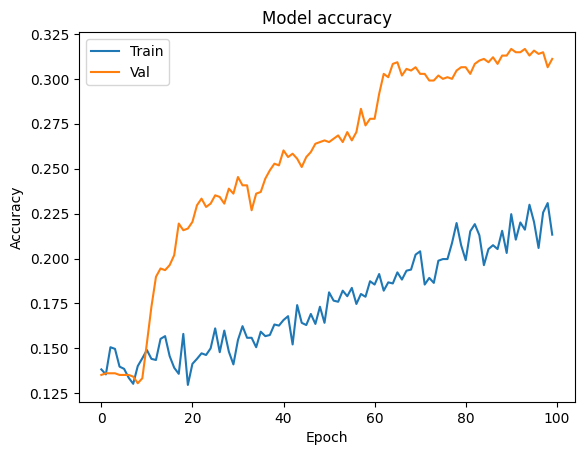

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

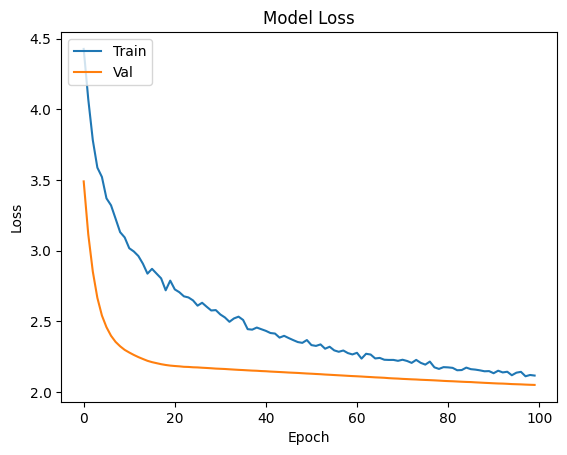

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

**Use the test data to do prediction**

In [38]:
y_pred = model.predict(XTestProcessed)

34/34 [==============================] - 1s 36ms/step


**Draw a confusion matrix**

<Axes: >

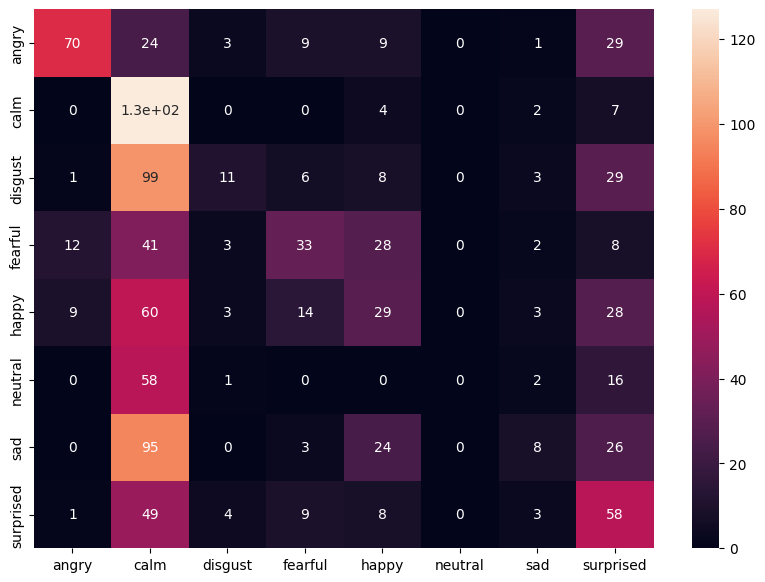

In [39]:
import seaborn as sn
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
confusion_emotions = ['angry', 'calm', 'disgust', 'fearful','happy','neutral','sad','surprised']
cm=metrics.confusion_matrix(y_test,np.argmax(y_pred,axis=-1))
df_cm=pd.DataFrame(cm,index=[i for i in confusion_emotions],columns=[i for i in confusion_emotions])
plt.figure(figsize=(10,7))
sn.heatmap(df_cm,annot=True)

**Calculate the F1 score of the model**

F1 score is a measure of a test's accuracy. F1 score combines precision and recall relative to a specific positive class - The F1 score can be interpreted as a weighted average of the precision and recall, where an F1 score reaches its best value at 1 and worst at 0

In [40]:
f1_score(y_test,np.argmax(y_pred,axis=-1),average='weighted')

0.2687162380779391

**Model summary**

In [41]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 180, 256)          1536      
                                                                 
 activation_5 (Activation)   (None, 180, 256)          0         
                                                                 
 conv1d_5 (Conv1D)           (None, 180, 128)          163968    
                                                                 
 activation_6 (Activation)   (None, 180, 128)          0         
                                                                 
 dropout_2 (Dropout)         (None, 180, 128)          0         
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 22, 128)           0         
 g1D)                                                            
                                                      

## 6. Save and load the trained model.

In [42]:
# Save the trained model to disk
if not os.path.exists('models'):
    os.makedirs('models')

model.save("models/cnn.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [43]:
# Load the model from disk
loaded_model = keras.models.load_model("models/cnn.h5")

## 7. Playground

In [44]:
# Load the data and extract features for each sound file
def load_single_data(file):
    x, y = [], []
    file_name = os.path.basename(file)
    emotion = emotions[file_name.split("-")[2]]
    data, sr = librosa.load(file)
    feature = extract_feature(data, sr, mfcc=True, chroma=True, mel=True)
    x.append(feature)
    y.append(emotion)
    return np.array(x), y

In [45]:
import os

# Define the root directory
root_dir = 'data/ravdess'

# Check if the directory exists
if os.path.exists(root_dir):
    print(f"Listing all files under {root_dir}:\n")
    # Walk through all subdirectories and files
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for file in filenames:
            print(os.path.join(dirpath, file))
else:
    print(f"Directory not found: {root_dir}")


Directory not found: data/ravdess


In [46]:
XX, yy = load_single_data("datasets/ravdess/Actor_01/03-01-05-02-02-02-01.wav")

In [47]:
yy

['angry']

In [48]:
# Predict for the test set
XXTemp=np.expand_dims(XX, axis=2)
XX, yy = load_single_data("datasets/ravdess/Actor_01/03-01-06-02-02-02-01.wav")
model.predict(XXTemp)


1/1 [==============================] - 0s 89ms/step


array([[8.9303422e-01, 4.3847049e-05, 1.3247406e-04, 1.0280211e-01,
        3.3504914e-03, 1.5635988e-04, 2.3306886e-04, 2.4742074e-04]],
      dtype=float32)

In [49]:
list(y_pred)

[array([0.09290662, 0.17137691, 0.15307274, 0.10936817, 0.11961864,
        0.08927263, 0.12778677, 0.13659754], dtype=float32),
 array([0.12531713, 0.12030699, 0.15226665, 0.11417168, 0.13425244,
        0.0784748 , 0.11826729, 0.15694305], dtype=float32),
 array([0.07239764, 0.21011305, 0.1399254 , 0.10154482, 0.09480705,
        0.09690117, 0.15840502, 0.12590589], dtype=float32),
 array([0.10853647, 0.11152647, 0.12708454, 0.14388971, 0.15427582,
        0.07886077, 0.13651423, 0.13931204], dtype=float32),
 array([0.07719324, 0.18963873, 0.15868197, 0.09869391, 0.10473336,
        0.08797722, 0.14350809, 0.13957347], dtype=float32),
 array([0.08975417, 0.15881287, 0.13825893, 0.11922973, 0.1269775 ,
        0.08335298, 0.1360802 , 0.14753358], dtype=float32),
 array([0.16176221, 0.09513728, 0.12468932, 0.15162313, 0.14302012,
        0.07072441, 0.10935315, 0.14369023], dtype=float32),
 array([0.09508123, 0.15169594, 0.13680057, 0.11743514, 0.11191162,
        0.10123222, 0.1492438